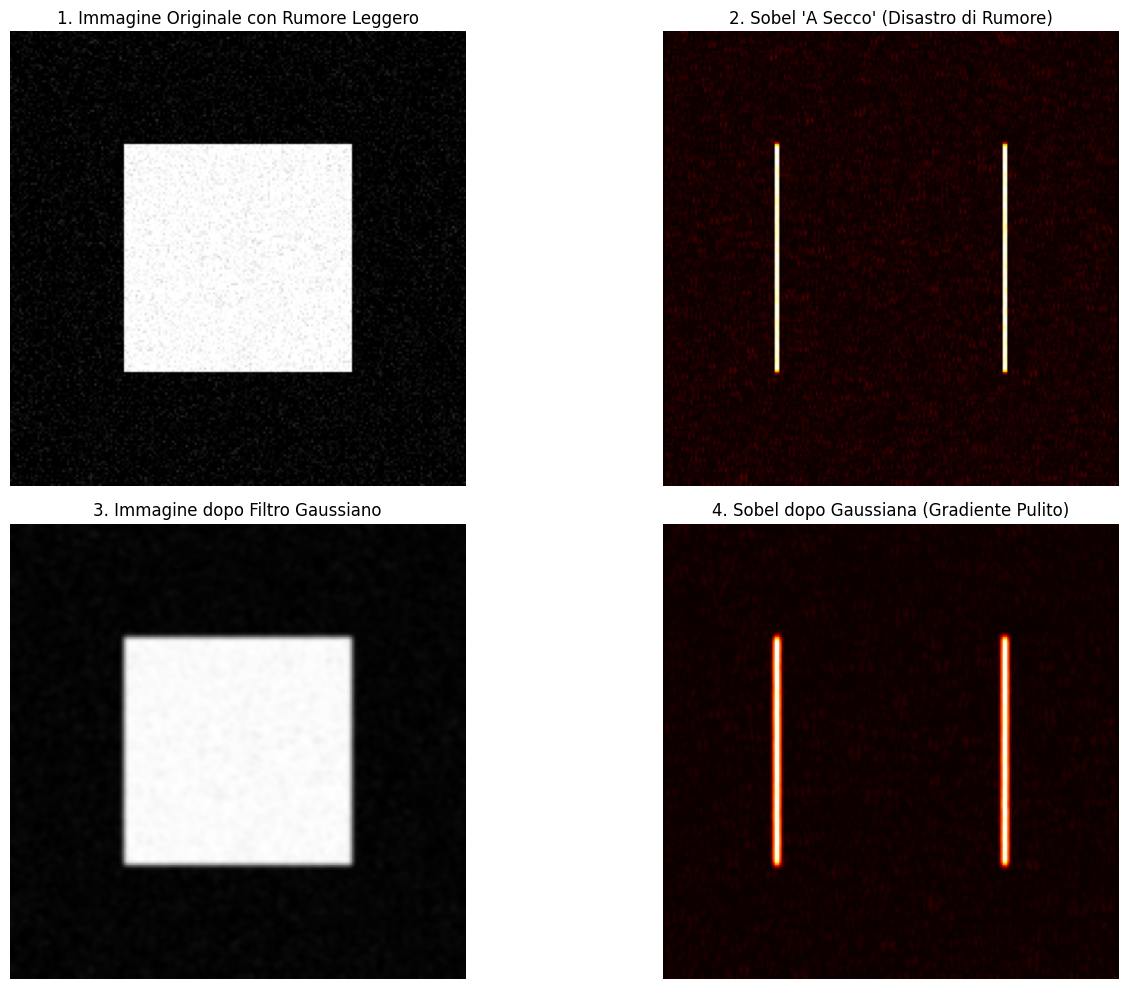

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Creiamo un'immagine artificiale pulita (un quadrato bianco su sfondo nero)
img_clean = np.zeros((200, 200), dtype=np.float32)
img_clean[50:150, 50:150] = 1.0  # Quadrato bianco

# 2. Aggiungiamo un leggerissimo rumore Gaussiano (quasi invisibile a occhio nudo)
noise = np.random.normal(0, 0.05, img_clean.shape).astype(np.float32)
img_noisy = np.clip(img_clean + noise, 0, 1)

# 3. Applichiamo Sobel X direttamente sull'immagine rumorosa ("a secco")
sobel_x_direct = cv2.Sobel(img_noisy, cv2.CV_32F, 1, 0, ksize=3)

# 4. Applichiamo prima lo smoothing Gaussiano e POI Sobel X
img_blurred = cv2.GaussianBlur(img_noisy, (5, 5), 0)
sobel_x_mitigated = cv2.Sobel(img_blurred, cv2.CV_32F, 1, 0, ksize=3)

# 5. Visualizziamo i risultati
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.title("1. Immagine Originale con Rumore Leggero")
plt.imshow(img_noisy, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("2. Sobel 'A Secco' (Disastro di Rumore)")
plt.imshow(np.abs(sobel_x_direct), cmap='hot')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("3. Immagine dopo Filtro Gaussiano")
plt.imshow(img_blurred, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("4. Sobel dopo Gaussiana (Gradiente Pulito)")
plt.imshow(np.abs(sobel_x_mitigated), cmap='hot')
plt.axis('off')

plt.tight_layout()
plt.show()

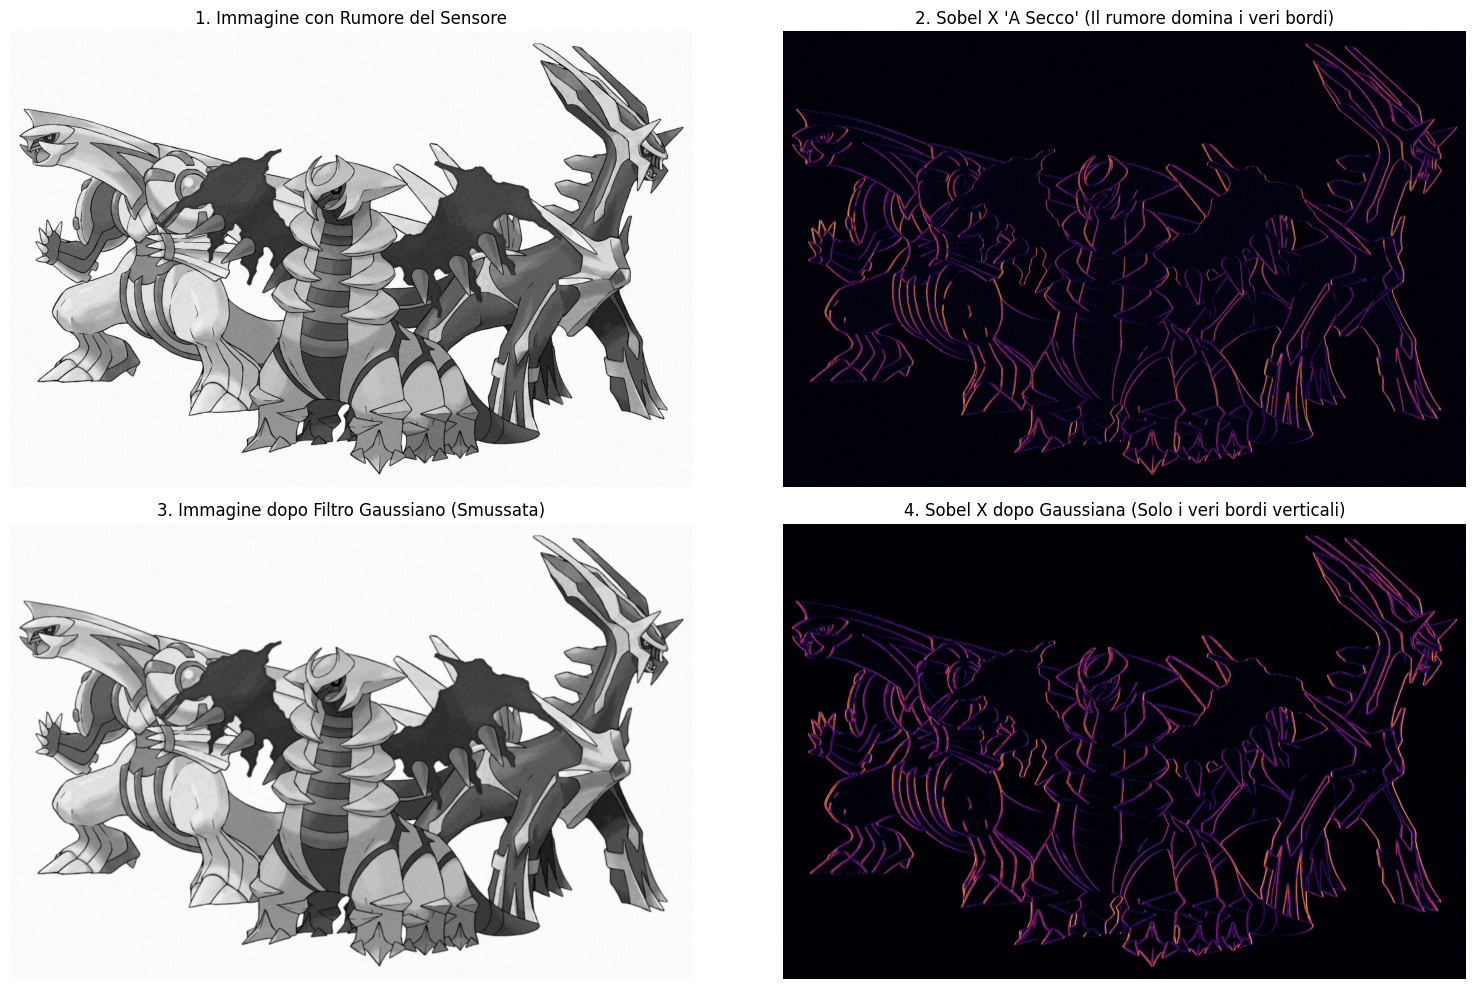

In [4]:
# %%
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Carichiamo l'immagine LOCALE usando cv2.imread in scala di grigi
path_immagine = '../images/mosketeers.jpg'
img_original = cv2.imread(path_immagine, cv2.IMREAD_GRAYSCALE)

# Controllo di sicurezza: verifichiamo se l'immagine è stata effettivamente trovata
if img_original is None:
    raise FileNotFoundError(f"Non ho trovato l'immagine al percorso: {path_immagine}. Controlla che cartella e nome file siano corretti!")

# Normalizziamo l'immagine tra 0 e 1 per gestire meglio il rumore numerico
img_original = img_original.astype(np.float32) / 255.0

# 2. Aggiungiamo un rumore Gaussiano del sensore (piccolo, ma letale per le derivate)
noise = np.random.normal(0, 0.04, img_original.shape).astype(np.float32)
img_noisy = np.clip(img_original + noise, 0, 1)

# 3. Applichiamo Sobel X direttamente sull'immagine rumorosa ("a secco")
sobel_x_direct = cv2.Sobel(img_noisy, cv2.CV_32F, 1, 0, ksize=3)

# 4. Applichiamo prima lo smoothing Gaussiano e POI Sobel X
img_blurred = cv2.GaussianBlur(img_noisy, (5, 5), 0)
sobel_x_mitigated = cv2.Sobel(img_blurred, cv2.CV_32F, 1, 0, ksize=3)

# 5. Visualizziamo il confronto
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.title("1. Immagine con Rumore del Sensore")
plt.imshow(img_noisy, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title("2. Sobel X 'A Secco' (Il rumore domina i veri bordi)")
plt.imshow(np.abs(sobel_x_direct), cmap='inferno')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title("3. Immagine dopo Filtro Gaussiano (Smussata)")
plt.imshow(img_blurred, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title("4. Sobel X dopo Gaussiana (Solo i veri bordi verticali)")
plt.imshow(np.abs(sobel_x_mitigated), cmap='inferno')
plt.axis('off')

plt.tight_layout()
plt.show()

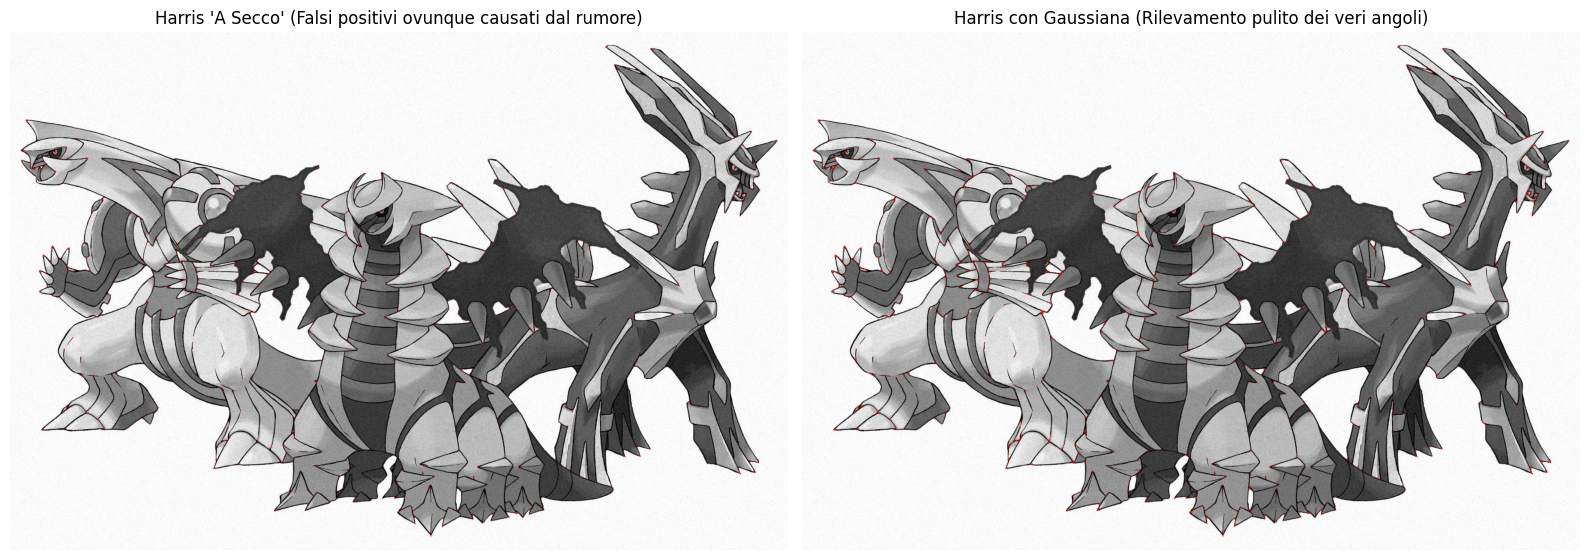

In [5]:
# %%
# Calcoliamo la risposta di Harris su entrambe le versioni

# 1. Harris "A secco" (Sobel diretto sul rumore)
# ksize=3 usa Sobel internamente. 0.04 è il parametro k di Harris
harris_raw = cv2.cornerHarris(img_noisy, blockSize=2, ksize=3, k=0.04)
# Normalizziamo per la visualizzazione
harris_raw_normalized = cv2.normalize(harris_raw, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 2. Harris con pre-filtering Gaussiano
img_blurred_uint8 = (img_blurred * 255).astype(np.uint8)
harris_mitigated = cv2.cornerHarris(img_blurred_uint8, blockSize=2, ksize=3, k=0.04)
harris_mitigated_normalized = cv2.normalize(harris_mitigated, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 3. Creiamo copie dell'immagine per disegnarci sopra i cerchi dei finti/veri angoli
img_corners_raw = cv2.cvtColor((img_noisy * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
img_corners_mitigated = cv2.cvtColor((img_noisy * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)

# Soglia: se la risposta di Harris è superiore all'1% del valore massimo, lo consideriamo un angolo
img_corners_raw[harris_raw > 0.01 * harris_raw.max()] = [0, 0, 255]
img_corners_mitigated[harris_mitigated > 0.01 * harris_mitigated.max()] = [0, 0, 255]

# Visualizziamo il verdetto finale di Harris
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.title("Harris 'A Secco' (Falsi positivi ovunque causati dal rumore)")
plt.imshow(cv2.cvtColor(img_corners_raw, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Harris con Gaussiana (Rilevamento pulito dei veri angoli)")
plt.imshow(cv2.cvtColor(img_corners_mitigated, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()